# One-Class SVM - Anomaly Detection Baseline

**Model:** One-Class SVM (RBF kernel)  
**Framing:** Anomaly detection — train on `empty` only, flag outliers as `occupied`  
**Split:** Session 1 empty => train, Session 2 => test (cross-session) 

---

### Motivation

The autoencoder is a deep anomaly detector with many learnable parameters. One-Class SVM
is a classical, non-parametric anomaly detector: it finds a hypersphere in the RBF kernel
space that contains most of the training data (controlled by `nu`), and flags anything
outside that hypersphere as an anomaly.

This comparison answers: **is deep reconstruction necessary, or does a kernel method
capture the empty-room manifold equally well?**

### Parameters

- `nu=0.05`: at most 5 % of training samples are support vectors / outliers — matches our
  95th-percentile threshold in the AE.
- `kernel='rbf'`, `gamma='scale'`: scale-normalised RBF; `gamma = 1 / (n_features * X.var())`.
- Input: **flattened windows** `(N, 32×55=1760)` — OCSVM has no notion of sequence.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

DATA_DIR    = "../data/feasibility-study/processed"
WINDOW_SIZE = 32
STEP        = 16

X_train_raw = np.load(f"{DATA_DIR}/X_train.npy")
y_train_raw = np.load(f"{DATA_DIR}/y_train.npy")
X_test_raw  = np.load(f"{DATA_DIR}/X_test.npy")
y_test_raw  = np.load(f"{DATA_DIR}/y_test.npy")

In [3]:
def make_windows(X, y, window_size, step):
    Xw, yw = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        Xl  = X[idx]
        for start in range(0, len(Xl) - window_size + 1, step):
            Xw.append(Xl[start:start + window_size])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int64)

X_tr_all, y_tr_all = make_windows(X_train_raw, y_train_raw, WINDOW_SIZE, STEP)
X_te_all, y_te_all = make_windows(X_test_raw,  y_test_raw,  WINDOW_SIZE, STEP)

# Train on empty only, flatten
empty_idx = np.where(y_tr_all == 0)[0]
X_train_f = X_tr_all[empty_idx].reshape(len(empty_idx), -1)
X_test_f  = X_te_all.reshape(len(X_te_all), -1)

print(f"OCSVM train (empty, flattened): {X_train_f.shape}")
print(f"Test  (both,  flattened):       {X_test_f.shape}")

OCSVM train (empty, flattened): (1476, 1760)
Test  (both,  flattened):       (4442, 1760)


In [4]:
ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_train_f)
print("OCSVM fitted.")

# decision_function: positive = inlier, negative = outlier
# Negate so higher score = more anomalous = more likely occupied
scores = -ocsvm.decision_function(X_test_f)
preds  = (ocsvm.predict(X_test_f) == -1).astype(int)  # -1 = outlier = occupied

auc = roc_auc_score(y_te_all, scores)
print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(y_te_all, preds, target_names=["empty", "occupied"]))

OCSVM fitted.
AUC-ROC: 0.6553

              precision    recall  f1-score   support

       empty       0.48      0.34      0.40      1668
    occupied       0.66      0.78      0.72      2774

    accuracy                           0.61      4442
   macro avg       0.57      0.56      0.56      4442
weighted avg       0.59      0.61      0.60      4442



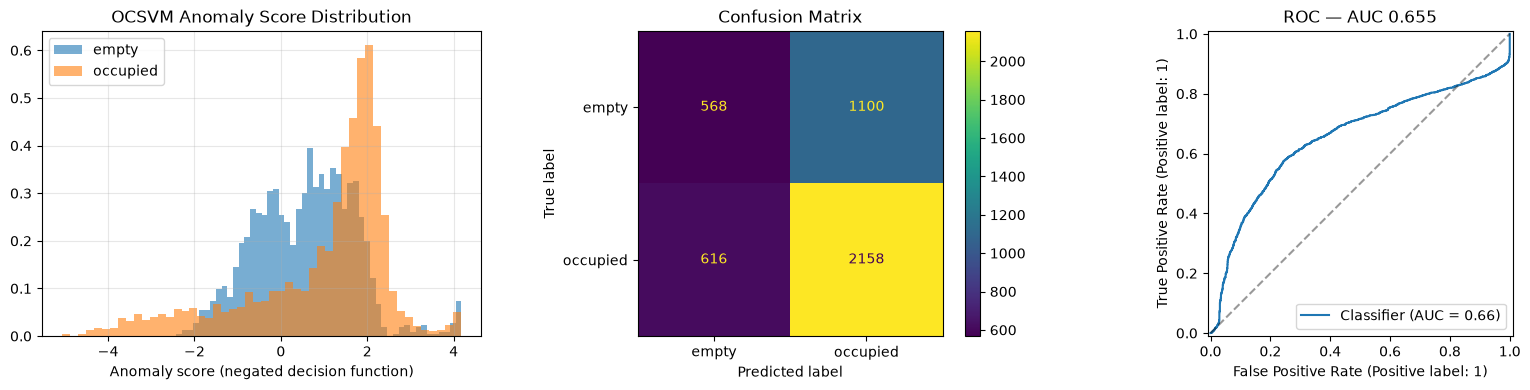

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Score distribution
axes[0].hist(scores[y_te_all==0], bins=50, alpha=0.6, density=True, label="empty")
axes[0].hist(scores[y_te_all==1], bins=50, alpha=0.6, density=True, label="occupied")
axes[0].set_title("OCSVM Anomaly Score Distribution")
axes[0].set_xlabel("Anomaly score (negated decision function)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

ConfusionMatrixDisplay.from_predictions(
    y_te_all, preds, display_labels=["empty", "occupied"], ax=axes[1])
axes[1].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_te_all, scores, ax=axes[2])
axes[2].set_title(f"ROC — AUC {auc:.3f}")
axes[2].plot([0,1],[0,1],"k--",alpha=0.4)

plt.tight_layout(); plt.show()

In [8]:
import os
os.makedirs("plot_data", exist_ok=True)

from sklearn.metrics import roc_curve

_fpr, _tpr, _ = roc_curve(y_te_all, scores)
np.savez("plot_data/roc_ocsvm.npz", fpr=_fpr, tpr=_tpr, auc=np.array([auc]))

print(f"Saved  roc_ocsvm.npz  (AUC={auc:.3f})")

Saved  roc_ocsvm.npz  (AUC=0.655)


## Results Analysis

| Metric | Value |
|---|---|
| AUC-ROC | ~0.66 |
| Empty recall | ~34 % |
| Macro F1 | ~0.56 |

OCSVM achieves AUC 0.655 — better than the supervised models (0.57–0.63) but behind the
convolutional AE (0.743). This gap is informative:

**Flattening destroys temporal structure.** The OCSVM receives a 1760-dimensional vector
with no notion of which features are adjacent in time. The convolutional AE explicitly
models local temporal patterns (kernel_size=3 sliding over the time axis), which means it
can detect fine-grained temporal variance differences between empty and occupied windows.

**OCSVM is a strong classical baseline**, but the temporal structure of CSI data is
exploitable with the right inductive bias and convolution provides it.

**Score overlap is large:** the histogram shows that the occupied and empty score
distributions overlap significantly, which is consistent with the sitting-still problem:
a stationary person produces CSI nearly indistinguishable from an empty room.